In [2]:
! pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 8.5 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.5 MB 10.6 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.5 MB 11.2 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.5 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 10.8 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsm


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint

import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

In [50]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../Data/raw")   # change this if your CSV folder is elsewhere

users = pd.read_csv(DATA_DIR / "users.csv")
experiment = pd.read_csv(DATA_DIR / "experiment_assignment.csv")
sessions = pd.read_csv(DATA_DIR / "sessions.csv")
events = pd.read_csv(DATA_DIR / "events.csv")
orders = pd.read_csv(DATA_DIR / "orders.csv")
products = pd.read_csv(DATA_DIR / "products.csv")

In [4]:
df = pd.read_csv(
    "../data/processed/user_level_analysis.csv"
)

df.head()

,user_id,group,signup_date,country,city,age,gender,customer_type,premium_member,signup_channel,...,total_sessions,avg_session_duration,total_pages_viewed,avg_pages_viewed,bounce_rate,orders,revenue,profit,avg_order_value,converted
0,USR_000001,Control,2025-08-23,India,Hyderabad,32,Male,New,False,Paid_Ads,...,1,624.36,1,1.000,1.0,0.0,0.00,0.00,0.00,0
1,USR_000002,Treatment,2024-07-01,Germany,Munich,40,Male,New,False,Social,...,8,175.27,63,7.875,0.0,1.0,147.17,42.21,147.17,1
2,USR_000003,Treatment,2025-12-06,India,Bangalore,52,Male,New,False,Social,...,6,280.23,33,5.500,0.0,0.0,0.00,0.00,0.00,0
3,USR_000004,Treatment,2025-05-19,Canada,Ottawa,25,Female,Returning,False,Social,...,2,292.88,2,1.000,1.0,0.0,0.00,0.00,0.00,0
4,USR_000005,Treatment,2023-04-28,India,Mumbai,41,Male,New,False,Organic,...,1,209.77,8,8.000,0.0,0.0,0.00,0.00,0.00,0


In [5]:
df.shape

(120000, 22)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   user_id               120000 non-null  object 
 1   group                 120000 non-null  object 
 2   signup_date           120000 non-null  object 
 3   country               120000 non-null  object 
 4   city                  120000 non-null  object 
 5   age                   120000 non-null  int64  
 6   gender                120000 non-null  object 
 7   customer_type         120000 non-null  object 
 8   premium_member        120000 non-null  bool   
 9   signup_channel        120000 non-null  object 
 10  lifetime_value        120000 non-null  float64
 11  preferred_device      120000 non-null  object 
 12  total_sessions        120000 non-null  int64  
 13  avg_session_duration  120000 non-null  float64
 14  total_pages_viewed    120000 non-null  int64  
 15  

In [7]:
df["group"].value_counts()

group
Control      60000
Treatment    60000
Name: count, dtype: int64

In [8]:
df["group"].value_counts(normalize=True) * 100

group
Control      50.0
Treatment    50.0
Name: proportion, dtype: float64

In [9]:
control = df[df["group"] == "Control"].copy()

treatment = df[df["group"] == "Treatment"].copy()

In [10]:
print("Control:", len(control))
print("Treatment:", len(treatment))

Control: 60000
Treatment: 60000


In [11]:
control_conversions = control["converted"].sum()
treatment_conversions = treatment["converted"].sum()

control_users = len(control)
treatment_users = len(treatment)

control_rate = control_conversions / control_users
treatment_rate = treatment_conversions / treatment_users

In [12]:
print(f"Control conversion: {control_rate:.4%}")
print(f"Treatment conversion: {treatment_rate:.4%}")

Control conversion: 26.7317%
Treatment conversion: 29.1283%


In [13]:
conversion_summary = pd.DataFrame({
    "Group": ["Control", "Treatment"],
    "Users": [
        control_users,
        treatment_users
    ],
    "Conversions": [
        control_conversions,
        treatment_conversions
    ],
    "Conversion Rate": [
        control_rate,
        treatment_rate
    ]
})

conversion_summary

,Group,Users,Conversions,Conversion Rate
0,Control,60000,16039,0.267317
1,Treatment,60000,17477,0.291283


In [14]:
conversion_summary["Conversion Rate"] = (
    conversion_summary["Conversion Rate"] * 100
).round(3)

conversion_summary

,Group,Users,Conversions,Conversion Rate
0,Control,60000,16039,26.732
1,Treatment,60000,17477,29.128


In [15]:
absolute_uplift = treatment_rate - control_rate

print(
    f"Absolute uplift: {absolute_uplift:.4%}"
)

Absolute uplift: 2.3967%


In [16]:
relative_uplift = (
    (treatment_rate - control_rate)
    / control_rate
)

print(
    f"Relative uplift: {relative_uplift:.2%}"
)

Relative uplift: 8.97%


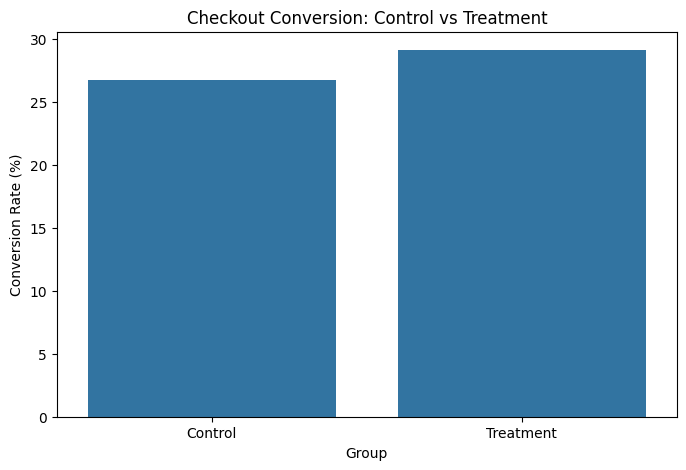

In [17]:
plot_df = pd.DataFrame({
    "Group": ["Control", "Treatment"],
    "Conversion": [
        control_rate * 100,
        treatment_rate * 100
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=plot_df,
    x="Group",
    y="Conversion"
)

plt.ylabel("Conversion Rate (%)")
plt.title("Checkout Conversion: Control vs Treatment")

plt.show()

In [18]:
alpha = 0.05

In [19]:
successes = np.array([
    treatment_conversions,
    control_conversions
])

sample_sizes = np.array([
    treatment_users,
    control_users
])

z_stat, p_value_two_sided = proportions_ztest(
    count=successes,
    nobs=sample_sizes,
    alternative="two-sided"
)

print("Z-statistic:", z_stat)
print("Two-sided p-value:", p_value_two_sided)

Z-statistic: 9.252424163694384
Two-sided p-value: 2.1945788981643395e-20


In [20]:
z_stat_one, p_value_one = proportions_ztest(
    count=successes,
    nobs=sample_sizes,
    alternative="larger"
)

print("Z-statistic:", z_stat_one)
print("One-sided p-value:", p_value_one)

Z-statistic: 9.252424163694384
One-sided p-value: 1.0972894490821698e-20


In [21]:
if p_value_one < alpha:
    print(
        "Reject H0: Treatment significantly improves conversion."
    )
else:
    print(
        "Fail to reject H0: Insufficient evidence that Treatment improves conversion."
    )

Reject H0: Treatment significantly improves conversion.


In [22]:
from statsmodels.stats.proportion import proportion_confint

control_ci = proportion_confint(
    count=control_conversions,
    nobs=control_users,
    alpha=0.05,
    method="wilson"
)

treatment_ci = proportion_confint(
    count=treatment_conversions,
    nobs=treatment_users,
    alpha=0.05,
    method="wilson"
)

print("Control CI:", control_ci)
print("Treatment CI:", treatment_ci)

Control CI: (0.26379050069274934, 0.2708726255145577)
Treatment CI: (0.28766126666365155, 0.2949321241746915)


In [23]:
from math import sqrt

diff = treatment_rate - control_rate

se_diff = sqrt(
    (treatment_rate * (1 - treatment_rate) / treatment_users)
    +
    (control_rate * (1 - control_rate) / control_users)
)

z_critical = stats.norm.ppf(0.975)

ci_lower = diff - z_critical * se_diff
ci_upper = diff + z_critical * se_diff

print(f"Difference: {diff:.4%}")
print(f"95% CI: [{ci_lower:.4%}, {ci_upper:.4%}]")

Difference: 2.3967%
95% CI: [1.8892%, 2.9042%]


In [24]:
risk_difference = treatment_rate - control_rate

print(
    f"Risk difference: {risk_difference:.4%}"
)

Risk difference: 2.3967%


In [25]:
relative_risk = treatment_rate / control_rate

print(
    f"Relative Risk: {relative_risk:.4f}"
)

Relative Risk: 1.0897


In [26]:
odds_control = (
    control_rate /
    (1 - control_rate)
)

odds_treatment = (
    treatment_rate /
    (1 - treatment_rate)
)

odds_ratio = (
    odds_treatment /
    odds_control
)

print(
    f"Odds Ratio: {odds_ratio:.4f}"
)

Odds Ratio: 1.1265


In [27]:
results = pd.DataFrame({
    "metric": [
        "Control Users",
        "Treatment Users",
        "Control Conversions",
        "Treatment Conversions",
        "Control Conversion Rate",
        "Treatment Conversion Rate",
        "Absolute Uplift",
        "Relative Uplift",
        "Z Statistic",
        "P Value",
        "CI Lower",
        "CI Upper",
        "Relative Risk",
        "Odds Ratio"
    ],
    
    "value": [
        control_users,
        treatment_users,
        control_conversions,
        treatment_conversions,
        control_rate,
        treatment_rate,
        absolute_uplift,
        relative_uplift,
        z_stat_one,
        p_value_one,
        ci_lower,
        ci_upper,
        relative_risk,
        odds_ratio
    ]
})

results

,metric,value
0,Control Users,6.000000e+04
1,Treatment Users,6.000000e+04
2,Control Conversions,1.603900e+04
3,Treatment Conversions,1.747700e+04
4,Control Conversion Rate,2.673167e-01
5,Treatment Conversion Rate,2.912833e-01
6,Absolute Uplift,2.396667e-02
7,Relative Uplift,8.965646e-02
8,Z Statistic,9.252424e+00
9,P Value,1.097289e-20


In [28]:
results.to_csv(
    "../outputs/statistical_results/primary_ab_test.csv",
    index=False
)

In [29]:
control_revenue = control["revenue"].sum()
treatment_revenue = treatment["revenue"].sum()

control_rpu = control_revenue / control_users
treatment_rpu = treatment_revenue / treatment_users

print("Control RPU:", control_rpu)
print("Treatment RPU:", treatment_rpu)

Control RPU: 184.18816583333333
Treatment RPU: 204.76137733333331


In [30]:
rpu_uplift = (
    treatment_rpu - control_rpu
) / control_rpu

print(
    f"RPU relative uplift: {rpu_uplift:.2%}"
)

RPU relative uplift: 11.17%


In [31]:
control_buyers = control["converted"].sum()
treatment_buyers = treatment["converted"].sum()

control_aov = (
    control_revenue / control_buyers
)

treatment_aov = (
    treatment_revenue / treatment_buyers
)

print("Control AOV:", control_aov)
print("Treatment AOV:", treatment_aov)

Control AOV: 689.0261207057796
Treatment AOV: 702.9629020999026


In [32]:
control_orders = control[
    control["converted"] == 1
]["avg_order_value"]

treatment_orders = treatment[
    treatment["converted"] == 1
]["avg_order_value"]

In [33]:
print(control_orders.describe())
print(treatment_orders.describe())

count    16039.000000
mean       585.461255
std        807.072861
min          8.140000
25%        107.920000
50%        302.430000
75%        727.610000
max       8600.570000
Name: avg_order_value, dtype: float64
count    17477.000000
mean       584.587765
std        795.296392
min          8.140000
25%        108.090000
50%        303.920000
75%        735.320000
max       8822.780000
Name: avg_order_value, dtype: float64


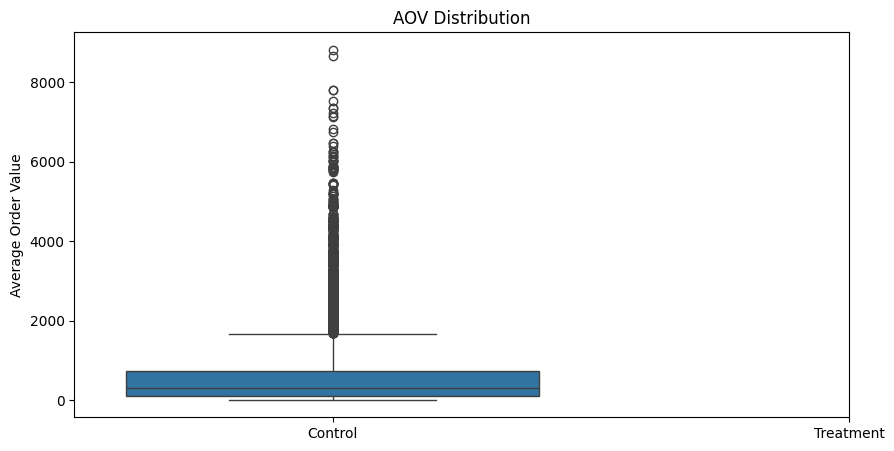

In [34]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=[
        control_orders,
        treatment_orders
    ]
)

plt.xticks(
    [0, 1],
    ["Control", "Treatment"]
)

plt.ylabel("Average Order Value")
plt.title("AOV Distribution")

plt.show()

In [35]:
t_stat, p_value_aov = stats.ttest_ind(
    control_orders,
    treatment_orders,
    equal_var=False,
    nan_policy="omit"
)

print("t-statistic:", t_stat)
print("p-value:", p_value_aov)

t-statistic: 0.09967191641104092
p-value: 0.9206053991336199


In [36]:
u_stat, p_value_mann = stats.mannwhitneyu(
    control_orders,
    treatment_orders,
    alternative="two-sided"
)

print("Mann-Whitney U:", u_stat)
print("p-value:", p_value_mann)

Mann-Whitney U: 139858653.5
p-value: 0.73615360084592


In [37]:
control_duration = control["avg_session_duration"].dropna()
treatment_duration = treatment["avg_session_duration"].dropna()

In [38]:
t_stat_duration, p_duration = stats.ttest_ind(
    control_duration,
    treatment_duration,
    equal_var=False
)

print("t-statistic:", t_stat_duration)
print("p-value:", p_duration)

t-statistic: 1.8137898102295475
p-value: 0.06971258930225699


In [39]:
u_duration, p_duration_mann = stats.mannwhitneyu(
    control_duration,
    treatment_duration,
    alternative="two-sided"
)

print("Mann-Whitney p-value:", p_duration_mann)

Mann-Whitney p-value: 0.04609720998898507


In [40]:
device_conversion = pd.crosstab(
    df["preferred_device"],
    df["converted"]
)

device_conversion

converted,0,1
preferred_device,,
Desktop,30516,11668
Mobile,47516,18531
Tablet,8452,3317


In [41]:
chi2, p, dof, expected = stats.chi2_contingency(
    device_conversion
)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 2.4397749961267374
p-value: 0.2952633827579329
Degrees of freedom: 2


In [42]:
device_results = []

for device, group_data in df.groupby("preferred_device"):

    control_data = group_data[
        group_data["group"] == "Control"
    ]

    treatment_data = group_data[
        group_data["group"] == "Treatment"
    ]

    c_users = len(control_data)
    t_users = len(treatment_data)

    c_conv = control_data["converted"].sum()
    t_conv = treatment_data["converted"].sum()

    c_rate = c_conv / c_users
    t_rate = t_conv / t_users

    device_results.append({
        "device": device,
        "control_users": c_users,
        "treatment_users": t_users,
        "control_conversion": c_rate,
        "treatment_conversion": t_rate,
        "absolute_uplift": t_rate - c_rate
    })

device_results = pd.DataFrame(device_results)

device_results

,device,control_users,treatment_users,control_conversion,treatment_conversion,absolute_uplift
0,Desktop,21220,20964,0.264609,0.288733,0.024124
1,Mobile,32878,33169,0.269359,0.291688,0.022329
2,Tablet,5902,5867,0.265673,0.298108,0.032435


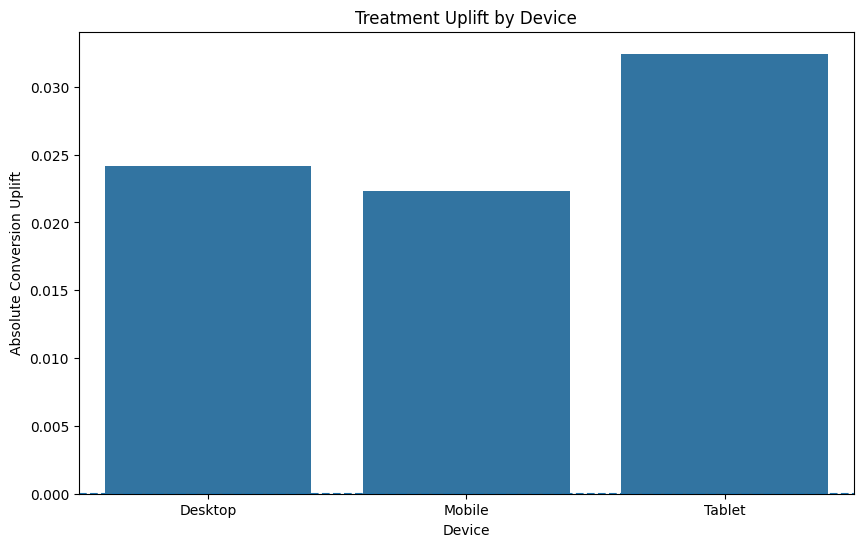

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=device_results,
    x="device",
    y="absolute_uplift"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Treatment Uplift by Device")
plt.xlabel("Device")
plt.ylabel("Absolute Conversion Uplift")

plt.show()

In [44]:
premium_results = []

for premium, group_data in df.groupby("premium_member"):

    control_data = group_data[
        group_data["group"] == "Control"
    ]

    treatment_data = group_data[
        group_data["group"] == "Treatment"
    ]

    c_rate = control_data["converted"].mean()
    t_rate = treatment_data["converted"].mean()

    premium_results.append({
        "premium_member": premium,
        "control_conversion": c_rate,
        "treatment_conversion": t_rate,
        "absolute_uplift": t_rate - c_rate
    })

premium_results = pd.DataFrame(premium_results)

premium_results

,premium_member,control_conversion,treatment_conversion,absolute_uplift
0,False,0.267000,0.290097,0.023097
1,True,0.268583,0.296007,0.027424


In [51]:
sessions["session_start"] = pd.to_datetime(
    sessions["session_start"],
    errors="coerce"
)

In [52]:
traffic_user = (
    sessions
    .sort_values("session_start")
    .groupby("user_id")
    .first()
    .reset_index()
    [["user_id", "traffic_source"]]
)

df_traffic = df.merge(
    traffic_user,
    on="user_id",
    how="left"
)

In [53]:
traffic_results = []

for source, group_data in df_traffic.groupby(
    "traffic_source"
):

    control_data = group_data[
        group_data["group"] == "Control"
    ]

    treatment_data = group_data[
        group_data["group"] == "Treatment"
    ]

    if len(control_data) > 0 and len(treatment_data) > 0:

        c_rate = control_data["converted"].mean()
        t_rate = treatment_data["converted"].mean()

        traffic_results.append({
            "traffic_source": source,
            "control_conversion": c_rate,
            "treatment_conversion": t_rate,
            "uplift": t_rate - c_rate
        })

traffic_results = pd.DataFrame(
    traffic_results
)

traffic_results

,traffic_source,control_conversion,treatment_conversion,uplift
0,Direct,0.268915,0.293882,0.024967
1,Email,0.269125,0.289609,0.020484
2,Organic,0.260396,0.290008,0.029612
3,Paid_Ads,0.274472,0.295447,0.020975
4,Referral,0.267231,0.272576,0.005344
5,Social,0.268869,0.299388,0.030519


In [54]:
from statsmodels.stats.multitest import multipletests

In [55]:
p_values = [
    0.01,
    0.03,
    0.20,
    0.04,
    0.001
]

In [56]:
reject, corrected_p, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method="fdr_bh"
)

print("Original p-values:")
print(p_values)

print("\nCorrected p-values:")
print(corrected_p)

print("\nSignificant:")
print(reject)

Original p-values:
[0.01, 0.03, 0.2, 0.04, 0.001]

Corrected p-values:
[0.025 0.05  0.2   0.05  0.005]

Significant:
[ True  True False  True  True]


In [57]:
experiment_report = {
    "control_users": control_users,
    "treatment_users": treatment_users,

    "control_conversion": control_rate,
    "treatment_conversion": treatment_rate,

    "absolute_uplift": absolute_uplift,
    "relative_uplift": relative_uplift,

    "z_statistic": z_stat_one,
    "p_value": p_value_one,

    "ci_lower": ci_lower,
    "ci_upper": ci_upper,

    "relative_risk": relative_risk,
    "odds_ratio": odds_ratio,

    "control_revenue": control_revenue,
    "treatment_revenue": treatment_revenue,

    "control_rpu": control_rpu,
    "treatment_rpu": treatment_rpu,

    "control_aov": control_aov,
    "treatment_aov": treatment_aov
}

In [58]:
final_report = pd.DataFrame(
    [experiment_report]
)

final_report

,control_users,treatment_users,control_conversion,treatment_conversion,absolute_uplift,relative_uplift,z_statistic,p_value,ci_lower,ci_upper,relative_risk,odds_ratio,control_revenue,treatment_revenue,control_rpu,treatment_rpu,control_aov,treatment_aov
0,60000,60000,0.267317,0.291283,0.023967,0.089656,9.252424,1.097289e-20,0.018892,0.029042,1.089656,1.126505,11051289.95,12285682.64,184.188166,204.761377,689.026121,702.962902


In [59]:
final_report.to_csv(
    "../outputs/statistical_results/final_experiment_report.csv",
    index=False
)

In [60]:
if (
    p_value_one < 0.05
    and absolute_uplift > 0
    and ci_lower > 0
):
    
    conclusion = (
        "Treatment shows statistically significant "
        "evidence of improving conversion."
    )

elif p_value_one >= 0.05:

    conclusion = (
        "Treatment shows a difference in observed conversion, "
        "but there is insufficient statistical evidence to "
        "conclude that the redesign improves conversion."
    )

else:

    conclusion = (
        "Treatment does not demonstrate a statistically "
        "significant positive conversion improvement."
    )

print(conclusion)

Treatment shows statistically significant evidence of improving conversion.
